## Bloco 1: Configuração e Descompactação

In [ ]:
import zipfile
import os

# Nome do arquivo zip (certifique-se de fazer o upload deste arquivo no Colab)
arquivo_zip = "amostras_automação.zip"
diretorio_extracao = "./amostras_extraidas"

# Verifica se o arquivo existe antes de tentar descompactar
if os.path.exists(arquivo_zip):
    print(f"Descompactando {arquivo_zip}...")
    with zipfile.ZipFile(arquivo_zip, 'r') as zip_ref:
        zip_ref.extractall(diretorio_extracao)
    print("Descompactação concluída!")
else:
    print(f"Erro: O arquivo '{arquivo_zip}' não foi encontrado. Faça o upload primeiro.")

Descompactando amostras_automação.zip...
Descompactação concluída!


## Bloco 2: Funções de Consolidação e Tratamento

In [ ]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual (igual ao seu notebook)
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

def consolidar_csvs_da_pasta(caminho_pasta):
    """
    Lê todos os arquivos .csv dentro de uma pasta, concatena-os e
    ordena pelo Timestamp para formar um único DataFrame contínuo.
    """
    # Procura por todos os arquivos csv na pasta
    arquivos_csv = glob.glob(os.path.join(caminho_pasta, "*.csv"))

    if not arquivos_csv:
        print(f"Aviso: Nenhum arquivo CSV encontrado em {caminho_pasta}")
        return pd.DataFrame()

    lista_dfs = []
    for arquivo in arquivos_csv:
        try:
            # Lê cada fragmento
            df_frag = pd.read_csv(arquivo)
            lista_dfs.append(df_frag)
        except Exception as e:
            print(f"Erro ao ler {arquivo}: {e}")

    if not lista_dfs:
        return pd.DataFrame()

    # Junta todos os fragmentos
    df_consolidado = pd.concat(lista_dfs, ignore_index=True)

    # Converte o timestamp para garantir a ordenação correta
    if 'SourceTimeStamp' in df_consolidado.columns:
        df_consolidado['SourceTimeStamp'] = pd.to_datetime(df_consolidado['SourceTimeStamp'])
        # Faz o "Merge" lógico ordenando pelo tempo
        df_consolidado = df_consolidado.sort_values('SourceTimeStamp').reset_index(drop=True)

    return df_consolidado

def tratar_dados_factory(df):
    """
    Aplica a lógica do notebook original: formata valores e pivota a tabela
    para ter colunas X, Y, Z indexadas pelo tempo.
    """
    if df.empty:
        return df

    try:
        # Garante que Value é numérico (Lógica do notebook)
        df['Value'] = pd.to_numeric(df['Value'], errors='coerce')

        # Pivotar (Transformar linhas em colunas - Lógica do notebook)
        # 2 -> X, 3 -> Y, 4 -> Z
        df_pivot = df.pivot_table(index='SourceTimeStamp',
                                  columns='PrimaryKey',
                                  values='Value',
                                  aggfunc='mean')

        # Renomear colunas para facilitar
        mapa_colunas = {2: 'X', 3: 'Y', 4: 'Z'}
        df_pivot = df_pivot.rename(columns=mapa_colunas)

        return df_pivot
    except Exception as e:
        print(f"Erro ao tratar dados: {e}")
        return pd.DataFrame()

## Bloco 3: Execução Principal (Mapeamento das Pastas)

In [ ]:
# Caminho base onde os arquivos foram extraídos
# Nota: O zip extrai criando uma pasta raiz com o mesmo nome geralmente
base_path = os.path.join(diretorio_extracao, "./")

# Dicionário mapeando o "Nome Amigável" -> "Nome da Pasta Real"
mapa_pastas = {
    "Sem Ruido": "100 Linhas sem ruído",
    "Ruido X": "100 Linhas com ruído em X",
    "Ruido Y": "100 Linhas com ruído em Y",
    "Ruido Z": "100 Linhas com ruído em Z"
}

bases_de_dados = {}

for nome_amigavel, nome_pasta in mapa_pastas.items():
    caminho_completo = os.path.join(base_path, nome_pasta)

    print(f"--- Processando pasta: {nome_pasta} ({nome_amigavel}) ---")

    # 1. Consolidar os CSVs da pasta (Merge pelo tempo)
    df_bruto = consolidar_csvs_da_pasta(caminho_completo)
    print(f"   Total de registros consolidados: {len(df_bruto)}")

    # 2. Aplicar o tratamento do notebook (Pivot e Rename)
    df_tratado = tratar_dados_factory(df_bruto)

    # Armazena para uso posterior
    bases_de_dados[nome_amigavel] = df_tratado

    print(df_tratado.head())
    print("\n")

--- Processando pasta: 100 Linhas sem ruído (Sem Ruido) ---
   Total de registros consolidados: 1057
PrimaryKey                         1        X        Y        Z
SourceTimeStamp                                                
2025-11-18 18:25:50.504000+00:00 NaN -2.06225 -1.04890      NaN
2025-11-18 18:25:50.795000+00:00 NaN -3.28084 -1.77590 -2.32476
2025-11-18 18:25:51.090000+00:00 NaN -4.26983 -2.36817 -3.23147
2025-11-18 18:25:51.385000+00:00 NaN -6.14377 -3.41774 -4.75752
2025-11-18 18:25:51.692000+00:00 NaN -4.88519 -2.68006 -3.73929


--- Processando pasta: 100 Linhas com ruído em X (Ruido X) ---
   Total de registros consolidados: 1088
PrimaryKey                         1        X        Y        Z
SourceTimeStamp                                                
2025-11-18 18:53:13.017000+00:00 NaN  4.14827      NaN      NaN
2025-11-18 18:53:13.295000+00:00 NaN  4.52277      NaN      NaN
2025-11-18 18:53:13.588000+00:00 NaN  4.30543  2.38561  3.32469
2025-11-18 18:53:13.91500

In [ ]:
# Exibir a tabela "Sem Ruído"
bases_de_dados["Sem Ruido"]


PrimaryKey,1,X,Y,Z
SourceTimeStamp,,,,
2025-11-18 18:25:50.504000+00:00,NaN,-2.06225,-1.04890,NaN
2025-11-18 18:25:50.795000+00:00,NaN,-3.28084,-1.77590,-2.32476
2025-11-18 18:25:51.090000+00:00,NaN,-4.26983,-2.36817,-3.23147
2025-11-18 18:25:51.385000+00:00,NaN,-6.14377,-3.41774,-4.75752
2025-11-18 18:25:51.692000+00:00,NaN,-4.88519,-2.68006,-3.73929
...,...,...,...,...
2025-11-18 18:27:30.385000+00:00,NaN,6.19424,3.43014,4.77283
2025-11-18 18:27:30.697000+00:00,NaN,5.59640,3.11481,4.33592
2025-11-18 18:27:30.993000+00:00,NaN,4.40022,2.45423,3.43497


In [ ]:
# Exibir a tabela "Ruído X"
bases_de_dados["Ruido X"]


PrimaryKey,1,X,Y,Z
SourceTimeStamp,,,,
2025-11-18 18:53:13.017000+00:00,NaN,4.148270,NaN,NaN
2025-11-18 18:53:13.295000+00:00,NaN,4.522770,NaN,NaN
2025-11-18 18:53:13.588000+00:00,NaN,4.305430,2.38561,3.32469
2025-11-18 18:53:13.915000+00:00,NaN,5.350620,2.99712,4.13069
2025-11-18 18:53:14.194000+00:00,NaN,4.876190,2.69756,3.76529
...,...,...,...,...
2025-11-18 18:54:56.202000+00:00,NaN,-5.130800,-2.83502,-3.87497
2025-11-18 18:54:56.512000+00:00,NaN,-4.582220,-2.55789,-3.51865
2025-11-18 18:54:56.791000+00:00,NaN,-2.291110,-2.32966,-3.25853


In [ ]:
# Exibir a tabela "Ruído Y"
bases_de_dados["Ruido Y"]


PrimaryKey,1,X,Y,Z
SourceTimeStamp,,,,
2025-11-18 18:58:42.761000+00:00,NaN,-2.571560,-2.34997,-3.291990
2025-11-18 18:58:43.073000+00:00,NaN,-1.285780,-2.42462,-3.345940
2025-11-18 18:58:43.384000+00:00,NaN,-0.321445,-2.53125,-2.985830
2025-11-18 18:58:43.680000+00:00,NaN,-0.080361,-2.33366,-0.746456
2025-11-18 18:58:43.959000+00:00,NaN,-0.020090,-3.00854,-0.186614
...,...,...,...,...
2025-11-18 19:00:17.578000+00:00,NaN,-3.261470,-1.74869,-2.199980
2025-11-18 19:00:17.857000+00:00,NaN,-5.114950,-2.83698,-3.901050
2025-11-18 19:00:18.167000+00:00,NaN,-4.758360,-2.61930,-3.650470


In [ ]:
# Exibir a tabela "Ruído Z"
bases_de_dados["Ruido Z"]


PrimaryKey,1,X,Y,Z
SourceTimeStamp,,,,
2025-11-18 19:06:18.720000+00:00,NaN,5.009840,2.75893,NaN
2025-11-18 19:06:19.016000+00:00,NaN,4.454430,2.47900,3.422420
2025-11-18 19:06:19.312000+00:00,NaN,4.112920,2.32060,3.204780
2025-11-18 19:06:19.621000+00:00,NaN,4.228280,2.35424,3.226330
2025-11-18 19:06:19.929000+00:00,NaN,4.357490,2.41328,3.381810
...,...,...,...,...
2025-11-18 19:07:54.410000+00:00,NaN,-0.278040,-2.42574,-3.394240
2025-11-18 19:07:54.733000+00:00,NaN,-0.069510,-2.35611,-3.299910
2025-11-18 19:07:55.022000+00:00,NaN,-0.017378,-2.41466,-3.374890


## Bloco 4: Plotagem dos Gráficos



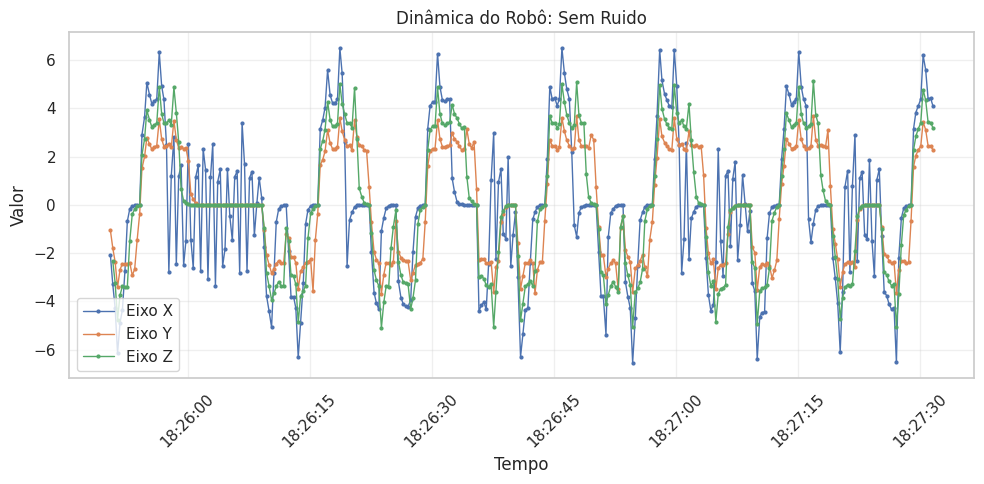

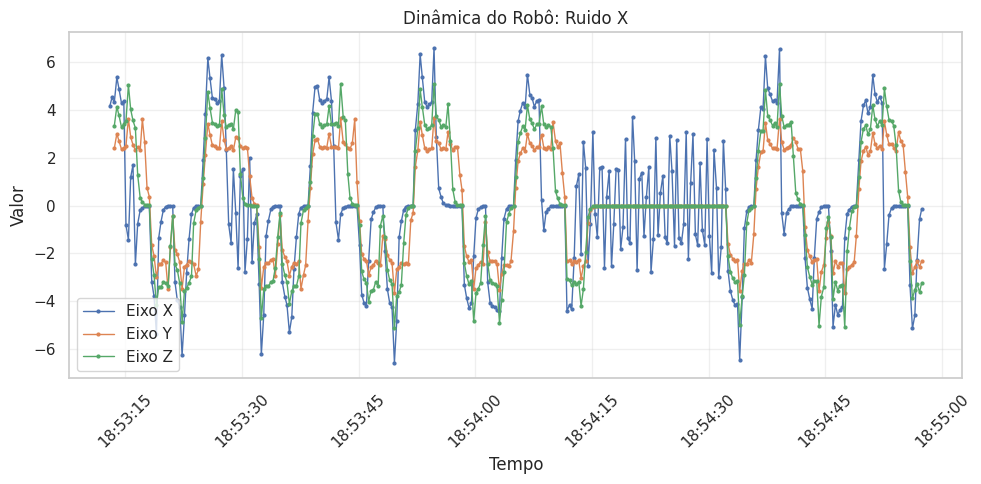

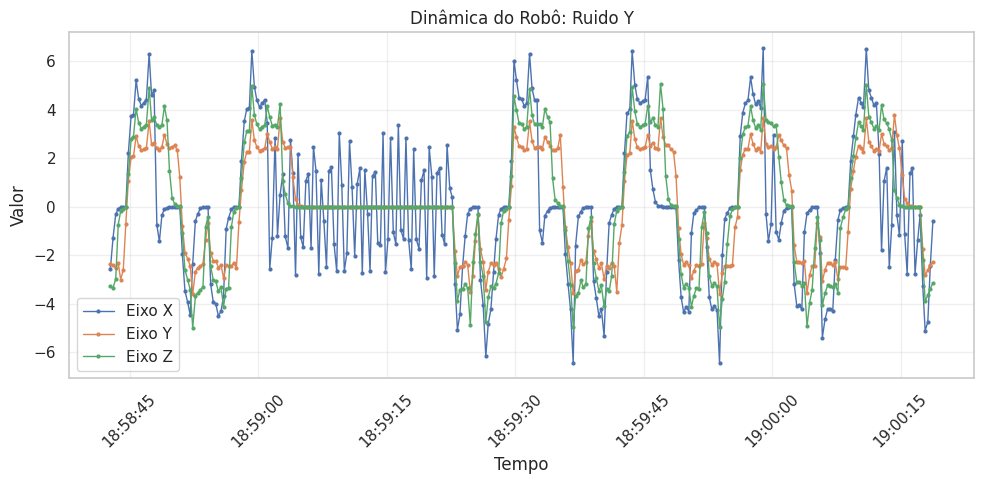

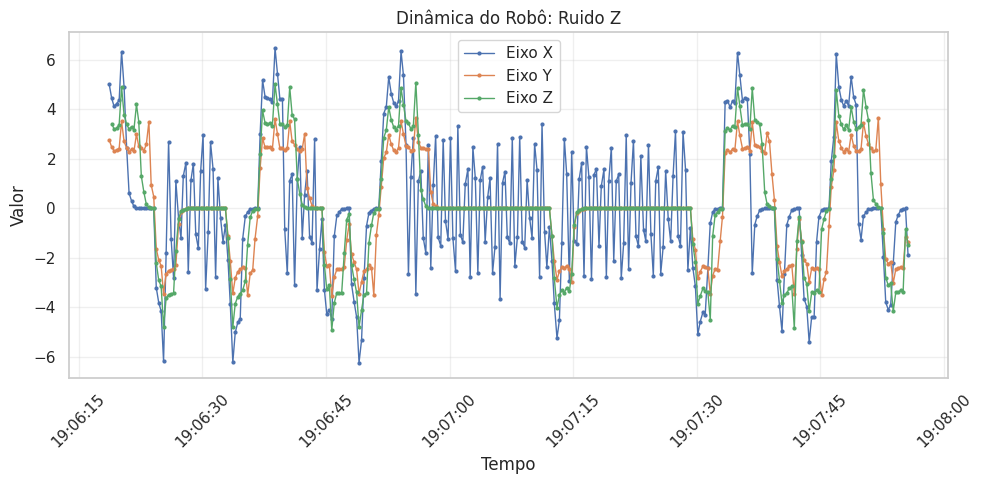

In [ ]:
# Iterar sobre cada base carregada e plotar
for nome, df in bases_de_dados.items():
    if df.empty:
        print(f"Dados vazios para {nome}, pulando gráfico.")
        continue

    plt.figure(figsize=(10, 5))

    # Plotar cada eixo disponível (X, Y, Z)
    for eixo in ['X', 'Y', 'Z']:
        if eixo in df.columns:
            plt.plot(df.index, df[eixo], marker='o', markersize=2, label=f'Eixo {eixo}', linewidth=1)

    plt.title(f"Dinâmica do Robô: {nome}")
    plt.xlabel("Tempo")
    plt.ylabel("Valor")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Bloco 5: Plotar Gráficos em Conjunto (Comparação)

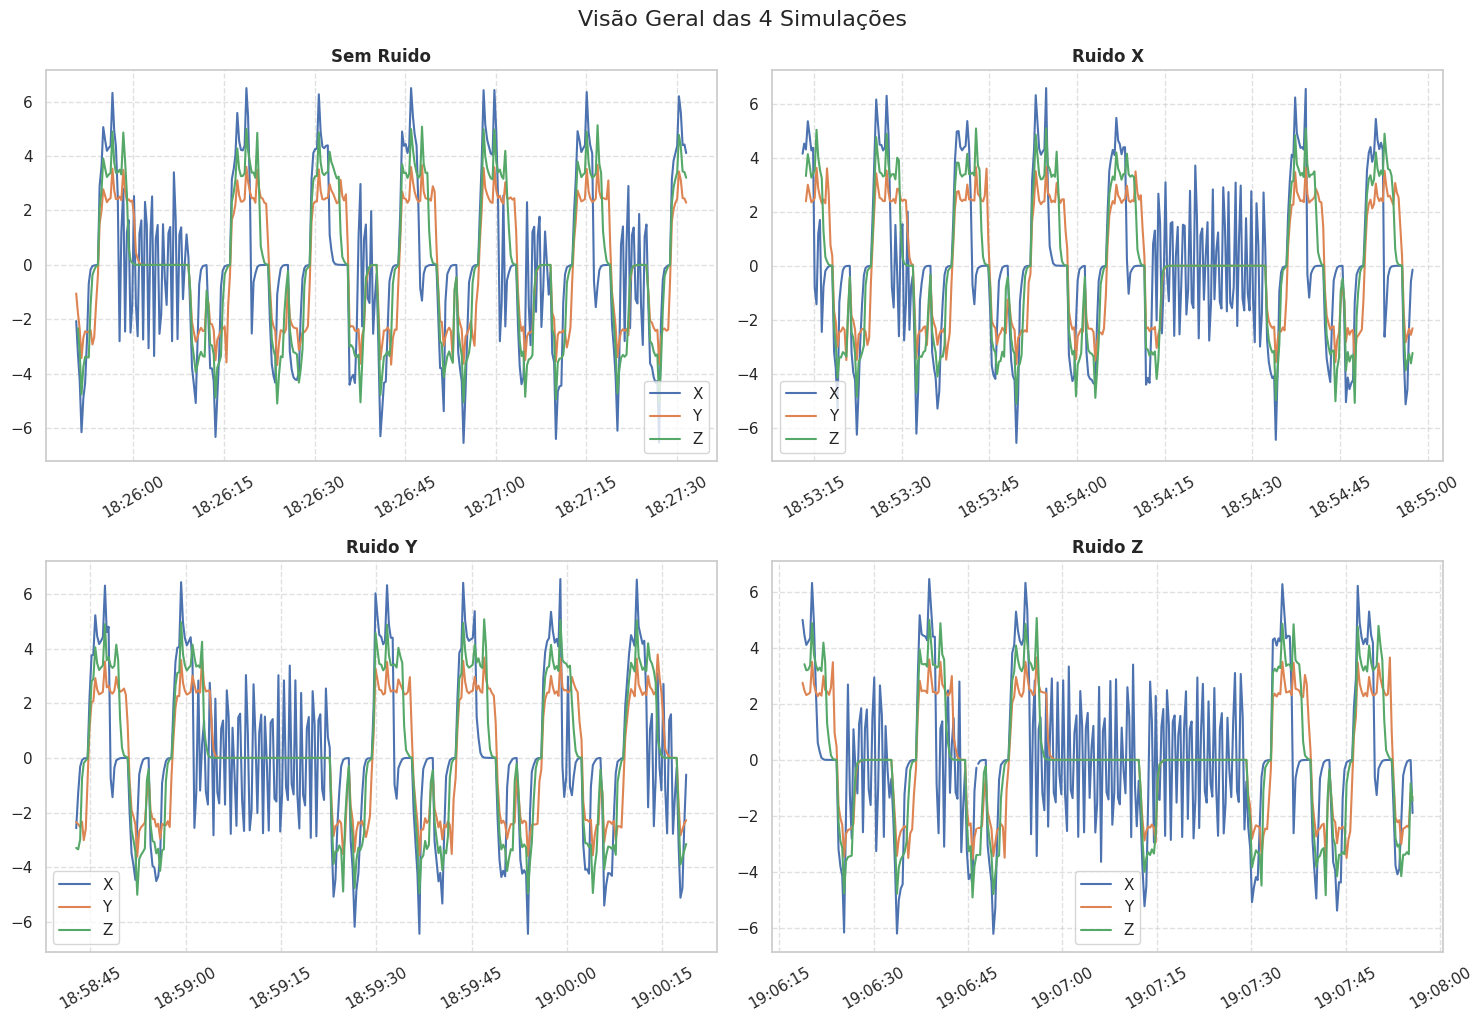

In [ ]:
# Criar uma figura com 2 linhas e 2 colunas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten() # Facilita iterar linearmente

for i, (nome, df) in enumerate(bases_de_dados.items()):
    ax = axes[i]

    if not df.empty:
        for eixo in ['X', 'Y', 'Z']:
            if eixo in df.columns:
                ax.plot(df.index, df[eixo], label=eixo)

        ax.set_title(nome, fontsize=12, fontweight='bold')
        ax.legend()
        ax.tick_params(axis='x', rotation=30)
        ax.grid(True, linestyle='--', alpha=0.6)
    else:
        ax.text(0.5, 0.5, 'Sem Dados', ha='center')

plt.tight_layout()
plt.suptitle("Visão Geral das 4 Simulações", y=1.02, fontsize=16)
plt.show()

## Script de Análise de Desvio Padrão

In [ ]:
import pandas as pd
from IPython.display import display

def gerar_tabela_diagnostico(dicionario_dfs):
    # Lista para guardar os dados de cada cenário
    lista_dados = []

    print("Calculando estatísticas nas bases processadas...")

    for cenario, df in dicionario_dfs.items():
        if df.empty:
            print(f"Aviso: O cenário '{cenario}' está vazio.")
            continue

        try:
            # --- ADAPTAÇÃO AO PIPELINE ---
            # Como já tratamos os dados no passo anterior, as colunas já são X, Y, Z.
            # Não precisamos do groupby('PrimaryKey'), apenas calcular o std() das colunas.
            stats = df[['X', 'Y', 'Z']].std()

            # Montar a linha da tabela
            linha = {'Cenário': cenario}

            maior_valor = -1
            eixo_dominante = "Indefinido"

            # Iterar sobre X, Y, Z para preencher a linha
            for eixo in ['X', 'Y', 'Z']:
                if eixo in stats:
                    valor = stats[eixo]
                    linha[f'Desvio {eixo}'] = valor

                    # Checar se é o maior desvio até agora (Identificar onde está o ruído)
                    if valor > maior_valor:
                        maior_valor = valor
                        eixo_dominante = eixo
                else:
                    linha[f'Desvio {eixo}'] = None

            linha['Maior Ruído Identificado'] = eixo_dominante
            lista_dados.append(linha)

        except Exception as e:
            print(f"Erro ao processar o cenário {cenario}: {e}")

    # Criar DataFrame Pandas Final
    df_resultado = pd.DataFrame(lista_dados)

    # Organizar colunas para ficarem bonitas na tabela
    colunas_desejadas = ['Cenário', 'Desvio X', 'Desvio Y', 'Desvio Z', 'Maior Ruído Identificado']
    # Garante que só selecionamos colunas que realmente existem (evita erro se faltar alguma)
    colunas_finais = [c for c in colunas_desejadas if c in df_resultado.columns]

    df_resultado = df_resultado[colunas_finais]

    return df_resultado

# --- Execução ---
# Passamos a variável 'bases_de_dados' que foi criada no bloco de código anterior
# e que contém os DataFrames já unidos e organizados por timestamp.
df_final = gerar_tabela_diagnostico(bases_de_dados)

# Exibir tabela formatada
print("\n=== TABELA DE ANÁLISE DE RUÍDO (DESVIO PADRÃO) ===")
display(df_final)

Calculando estatísticas nas bases processadas...

=== TABELA DE ANÁLISE DE RUÍDO (DESVIO PADRÃO) ===


,Cenário,Desvio X,Desvio Y,Desvio Z,Maior Ruído Identificado
0,Sem Ruido,3.004885,2.237078,2.768757,X
1,Ruido X,2.844482,2.197549,2.702013,X
2,Ruido Y,2.839459,2.140127,2.630234,X
3,Ruido Z,2.730582,1.931999,2.369076,X


## BLOCO 1: A Função de Suavização (Média Móvel)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de plotagem
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 7]

def calcular_comportamento_esperado(df_original, janela=100):
    """
    Aplica um filtro de média móvel para suavizar os dados e encontrar
    o comportamento médio esperado, removendo ruídos de alta frequência.

    Args:
        df_original (pd.DataFrame): O DataFrame com dados brutos (X, Y, Z).
        janela (int): O número de pontos para considerar na média.
                      Maior = mais liso, mas com mais atraso.
                      Menor = segue mais o ruído.
                      100 é um bom ponto de partida para esses dados.
    Returns:
        pd.DataFrame: DataFrame contendo apenas as curvas suavizadas.
    """
    if df_original.empty:
        return pd.DataFrame()

    # Garante que só vamos tentar suavizar as colunas numéricas de eixos
    colunas_eixos = [col for col in ['X', 'Y', 'Z'] if col in df_original.columns]

    # Aplica a média móvel (rolling mean)
    # min_periods=1 garante que o começo do gráfico não fique vazio (NaN)
    df_suavizado = df_original[colunas_eixos].rolling(window=janela, min_periods=1, center=False).mean()

    # O índice de tempo deve ser mantido para alinhamento
    df_suavizado.index = df_original.index

    return df_suavizado

print("Função de suavização criada com sucesso.")

Função de suavização criada com sucesso.


## BLOCO 2: Plotagem Comparativa (Original vs. Média)

--- Gerando Gráfico Comparativo: Sem Ruido ---


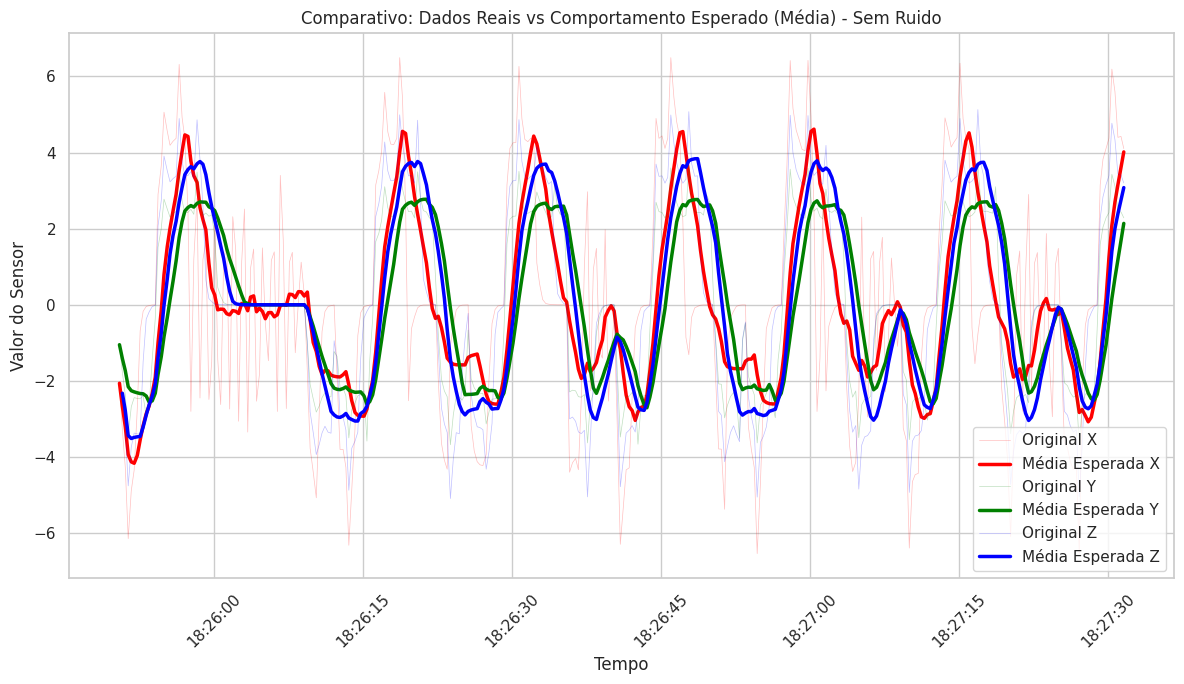



--- Gerando Gráfico Comparativo: Ruido X ---


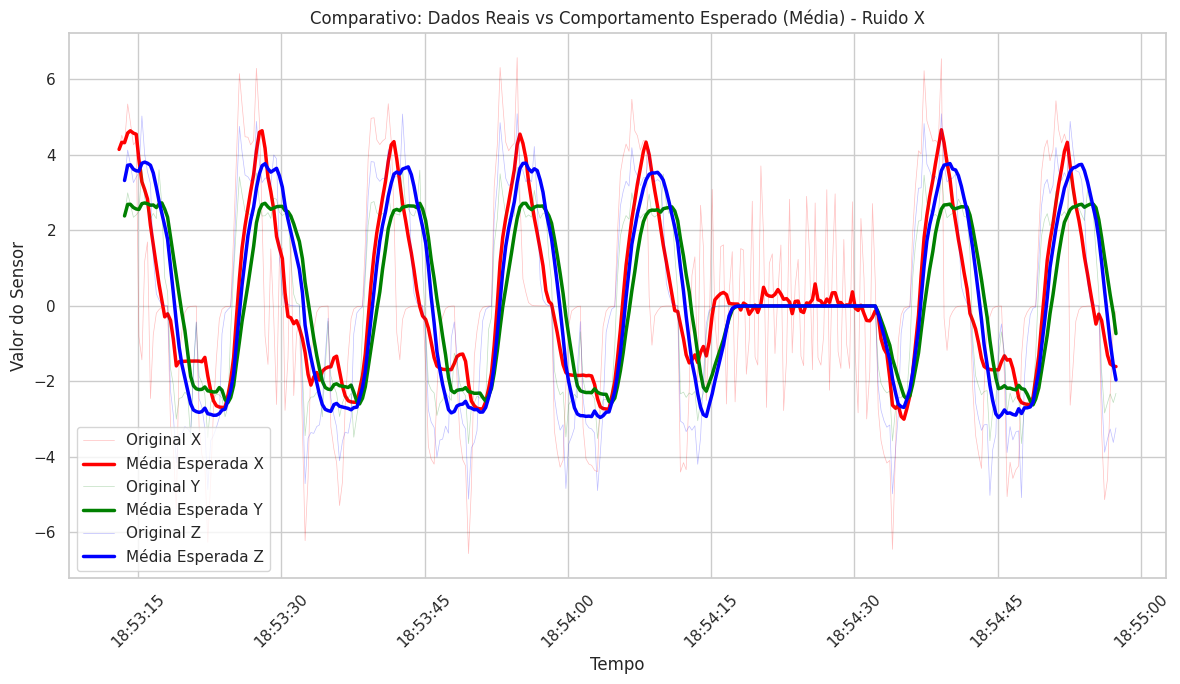



--- Gerando Gráfico Comparativo: Ruido Y ---


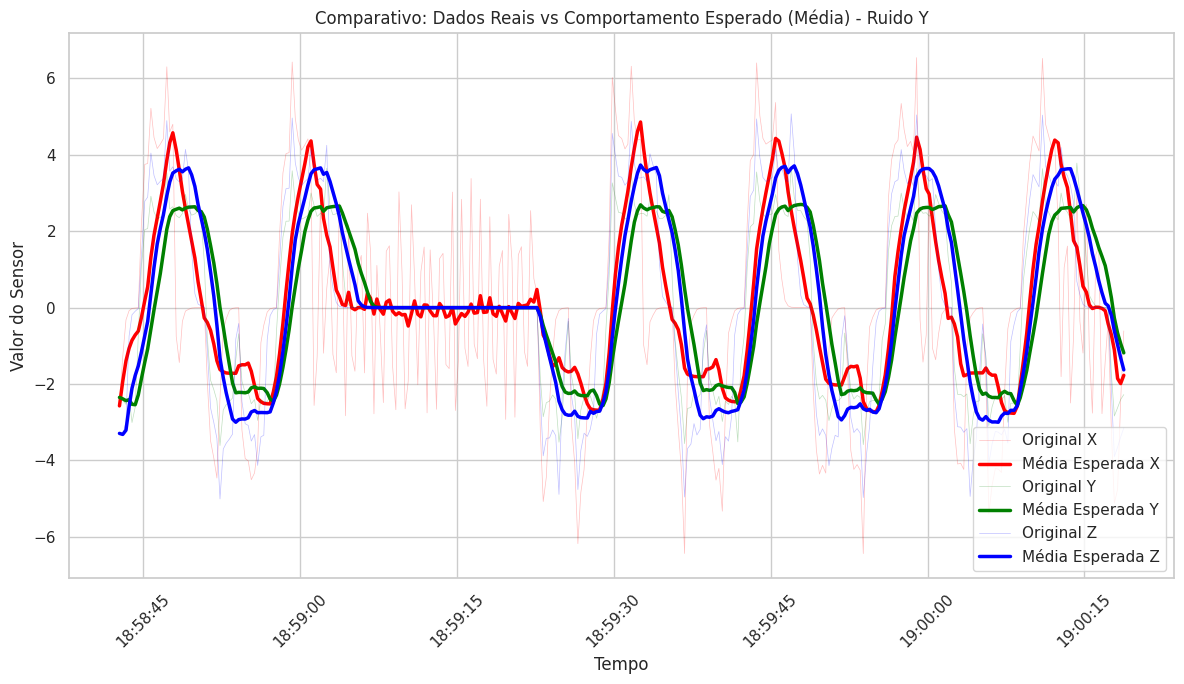



--- Gerando Gráfico Comparativo: Ruido Z ---


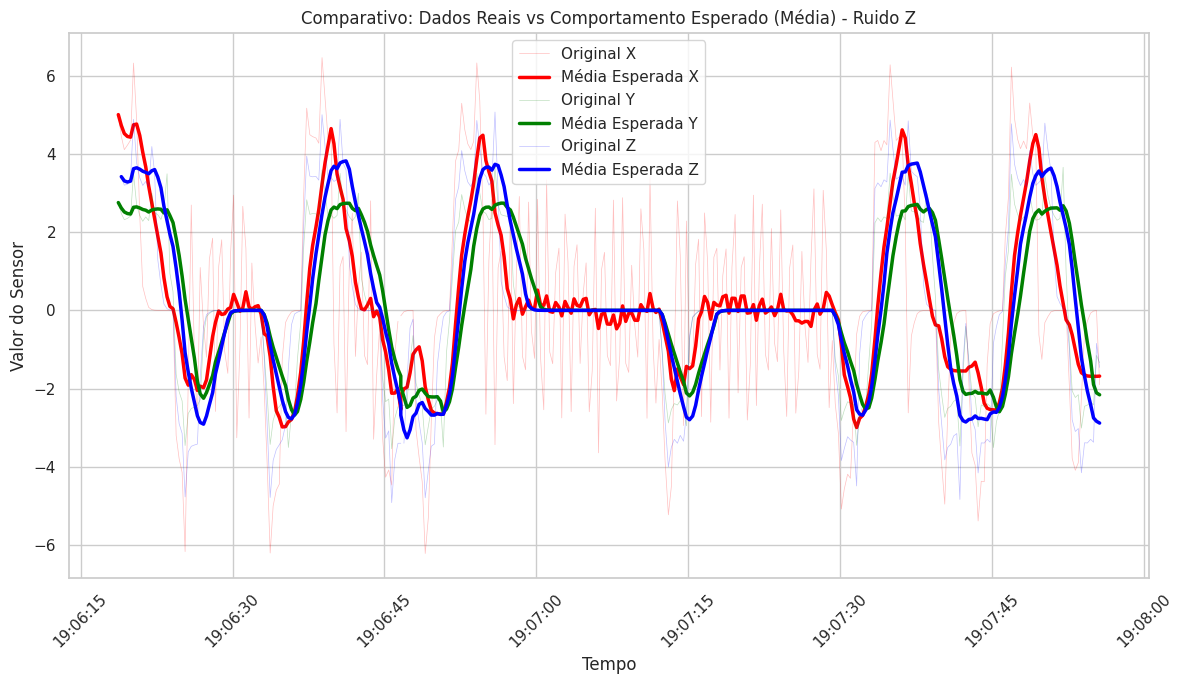

In [ ]:
# Dicionário para guardar as bases suavizadas para uso posterior
bases_suavizadas = {}

# Cores consistentes para os eixos
cores = {'X': 'red', 'Y': 'green', 'Z': 'blue'}

for nome_cenario, df_bruto in bases_de_dados.items():
    if df_bruto.empty: continue

    print(f"--- Gerando Gráfico Comparativo: {nome_cenario} ---")

    # 1. Calcular a média (usando a função do Bloco 1)
    # Você pode alterar o valor de 'janela' aqui se quiser testar: janela=50, janela=200...
    df_media = calcular_comportamento_esperado(df_bruto, janela=10)
    bases_suavizadas[nome_cenario] = df_media

    plt.figure()

    # Loop pelos eixos X, Y, Z disponíveis
    for eixo in cores.keys():
        if eixo in df_bruto.columns:
            # PLOT 1: Dados Originais (Ruidosos)
            # Linha fina e transparente (alpha=0.3) para ficar no fundo
            plt.plot(df_bruto.index, df_bruto[eixo],
                     color=cores[eixo],
                     linestyle='-',linewidth=0.5, alpha=0.25,
                    #  label=f'Original {eixo}' if eixo == 'X' else '') # Label só no X para não poluir a legenda
                     label=f'Original {eixo}')

            # PLOT 2: Dados Suavizados (Média)
            # Linha grossa e sólida
            plt.plot(df_media.index, df_media[eixo],
                     color=cores[eixo],
                     linestyle='-', linewidth=2.5,
                     label=f'Média Esperada {eixo}')

    plt.title(f"Comparativo: Dados Reais vs Comportamento Esperado (Média) - {nome_cenario}")
    plt.ylabel("Valor do Sensor")
    plt.xlabel("Tempo")
    # Legenda inteligente para não ficar gigante
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), loc='best')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    print("\n")

## BLOCO 3: Plotagem Apenas da Média (Comportamento Esperado)

--- Visualizando Apenas o Comportamento Esperado: Sem Ruido ---


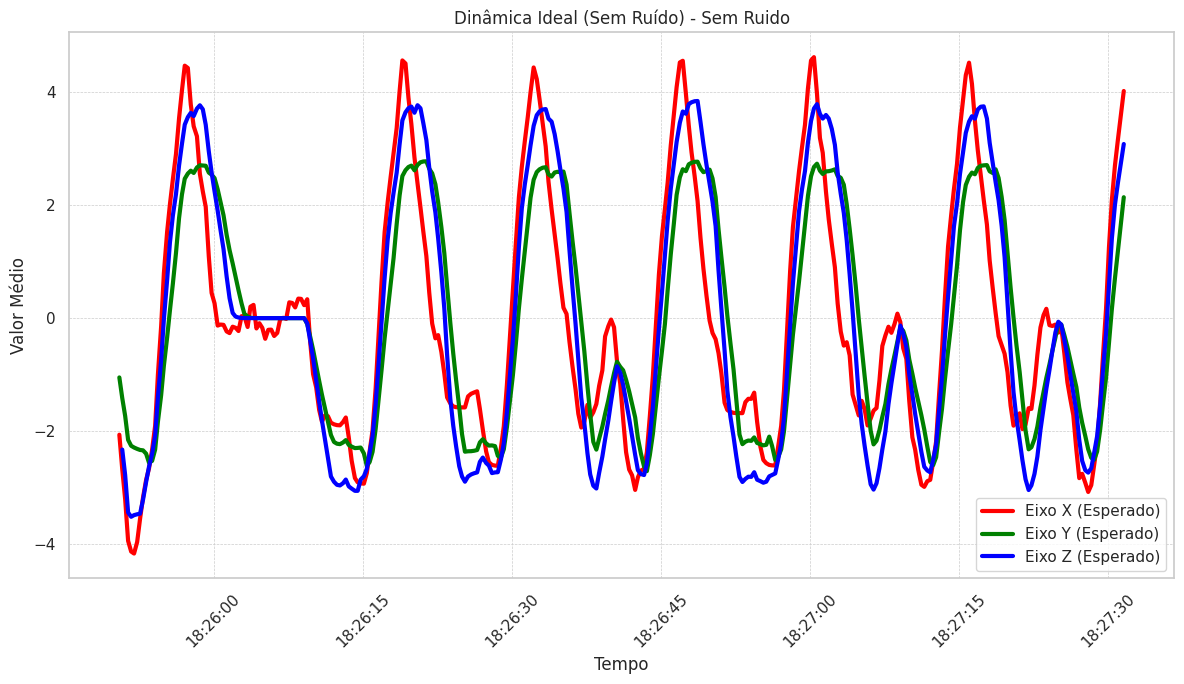

--- Visualizando Apenas o Comportamento Esperado: Ruido X ---


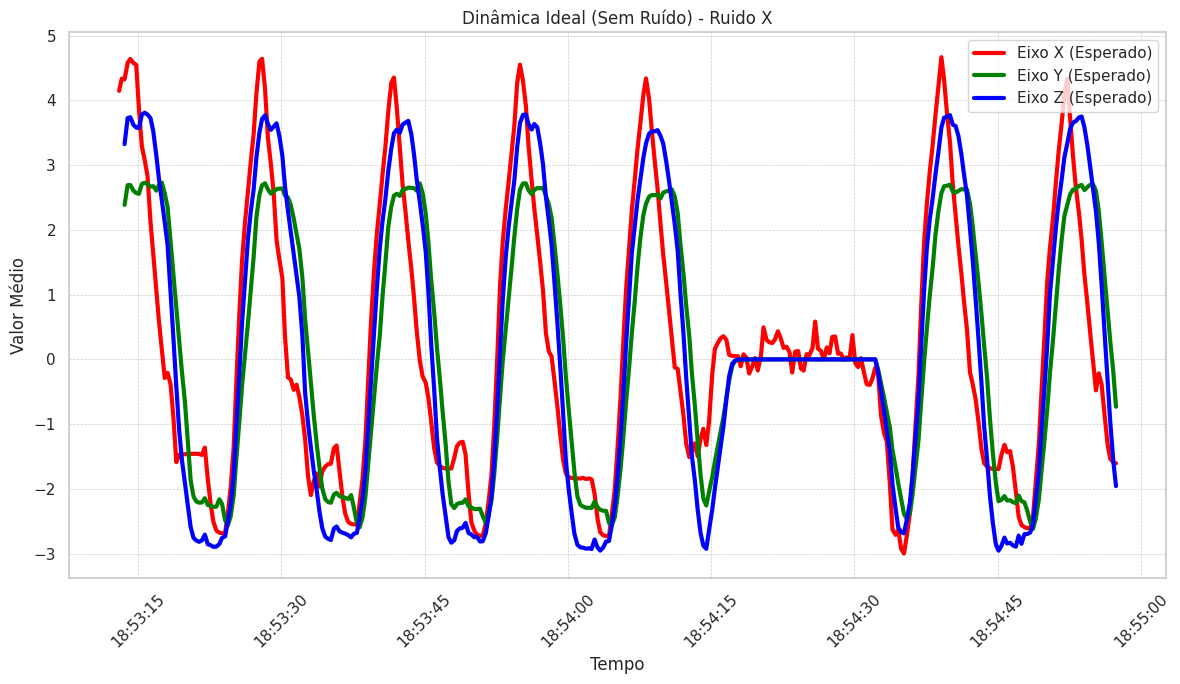

--- Visualizando Apenas o Comportamento Esperado: Ruido Y ---


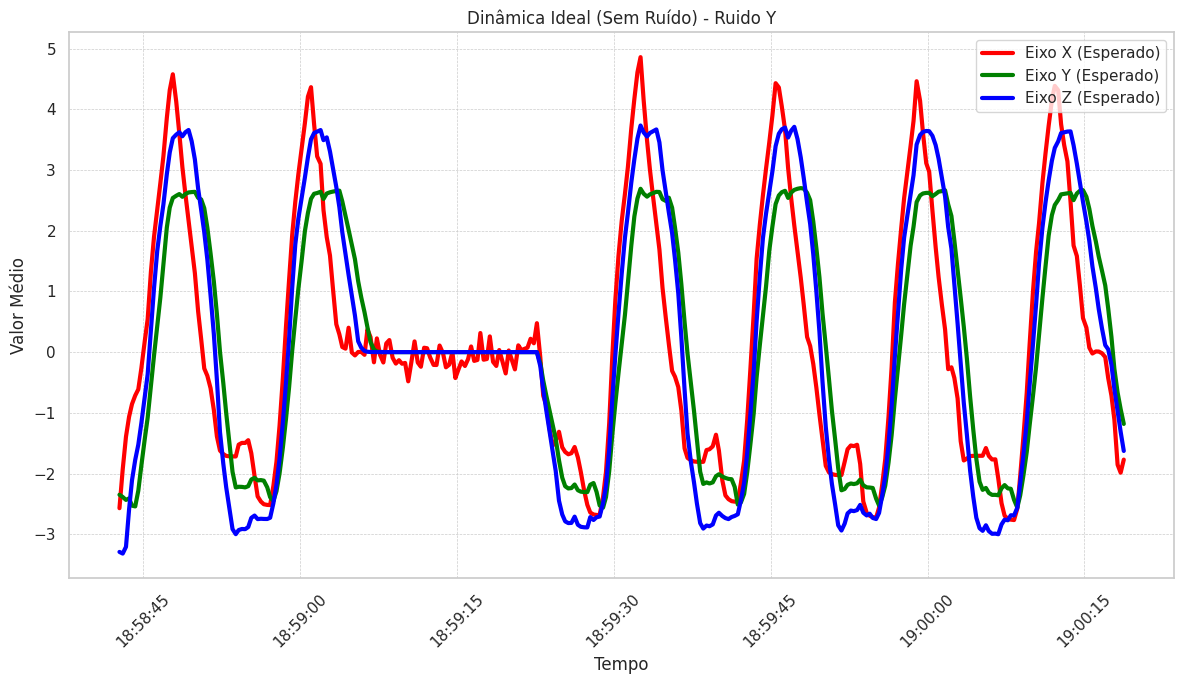

--- Visualizando Apenas o Comportamento Esperado: Ruido Z ---


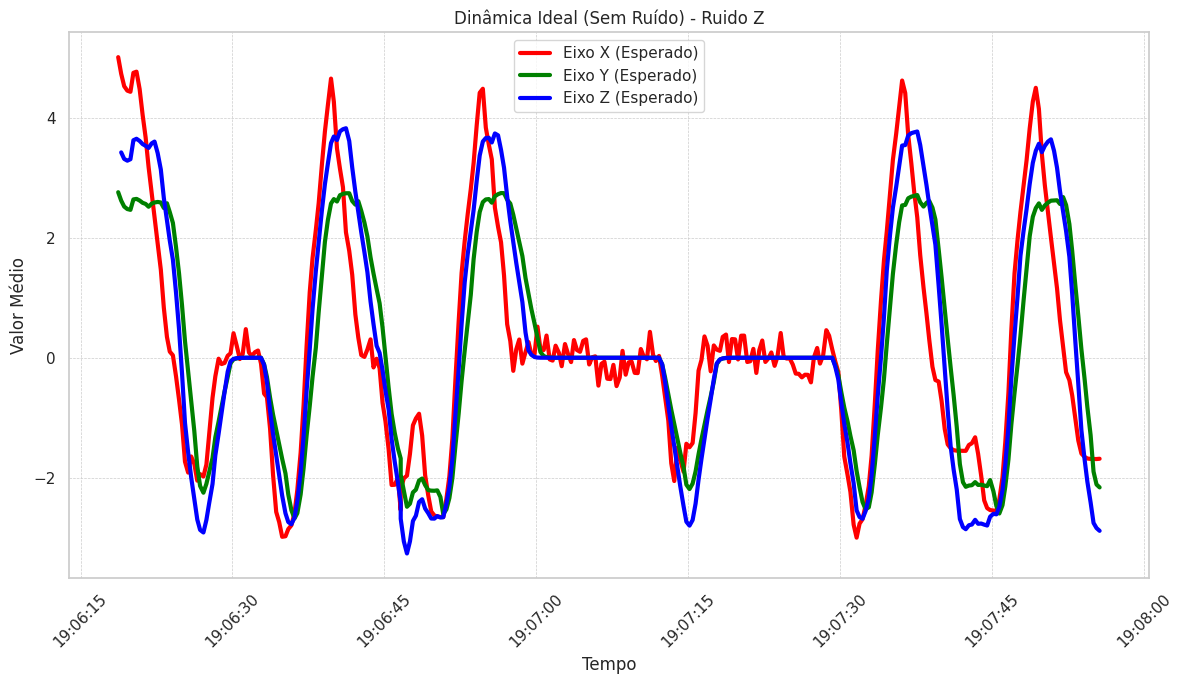

In [ ]:
for nome_cenario, df_media in bases_suavizadas.items():
    if df_media.empty: continue

    print(f"--- Visualizando Apenas o Comportamento Esperado: {nome_cenario} ---")

    plt.figure()

    for eixo, cor in cores.items():
        if eixo in df_media.columns:
            # Plota apenas a linha grossa da média calculada anteriormente
            plt.plot(df_media.index, df_media[eixo],
                     color=cor,
                     linestyle='-', linewidth=3,
                     label=f'Eixo {eixo} (Esperado)')

    plt.title(f"Dinâmica Ideal (Sem Ruído) - {nome_cenario}")
    plt.ylabel("Valor Médio")
    plt.xlabel("Tempo")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## BLOCO 4: Relatório Numérico (Antes vs. Depois)

In [ ]:
from IPython.display import display, HTML

print("=== RELATÓRIO NUMÉRICO: DADOS BRUTOS vs. MÉDIA CALCULADA ===\n")
print("Visualize como a aplicação da janela de média móvel alterou os valores.\n")

for nome_cenario, df_bruto in bases_de_dados.items():
    if df_bruto.empty or nome_cenario not in bases_suavizadas: continue

    df_suav = bases_suavizadas[nome_cenario]

    print("="*80)
    print(f" CENÁRIO: {nome_cenario.upper()} ")
    print("="*80)

    # --- Mostrando o Cabeçalho (Início do processo) ---
    print("\n---> AMOSTRA INICIAL (Primeiras 5 linhas)")

    # Cria dataframes menores apenas para exibição
    display_bruto_head = df_bruto[['X', 'Y', 'Z']].head(5).add_prefix('ORIGINAL_')
    display_suav_head = df_suav[['X', 'Y', 'Z']].head(5).add_prefix('MÉDIA_')

    # Junta lado a lado para facilitar comparação
    df_comparativo_head = pd.concat([display_bruto_head, display_suav_head], axis=1)
    display(df_comparativo_head)

    print("\n..." + " (Processamento de milhares de linhas) " + "...")

    # --- Mostrando o Rodapé (Final do processo, onde a média já está bem estabelecida) ---
    print("\n---> AMOSTRA FINAL (Últimas 5 linhas)")

    display_bruto_tail = df_bruto[['X', 'Y', 'Z']].tail(5).add_prefix('ORIGINAL_')
    display_suav_tail = df_suav[['X', 'Y', 'Z']].tail(5).add_prefix('MÉDIA_')

    df_comparativo_tail = pd.concat([display_bruto_tail, display_suav_tail], axis=1)
    display(df_comparativo_tail)
    print("\n\n")

=== RELATÓRIO NUMÉRICO: DADOS BRUTOS vs. MÉDIA CALCULADA ===

Visualize como a aplicação da janela de média móvel alterou os valores.

 CENÁRIO: SEM RUIDO 

---> AMOSTRA INICIAL (Primeiras 5 linhas)


PrimaryKey,ORIGINAL_X,ORIGINAL_Y,ORIGINAL_Z,MÉDIA_X,MÉDIA_Y,MÉDIA_Z
SourceTimeStamp,,,,,,
2025-11-18 18:25:50.504000+00:00,-2.06225,-1.04890,NaN,-2.062250,-1.048900,NaN
2025-11-18 18:25:50.795000+00:00,-3.28084,-1.77590,-2.32476,-2.671545,-1.412400,-2.324760
2025-11-18 18:25:51.090000+00:00,-4.26983,-2.36817,-3.23147,-3.204307,-1.730990,-2.778115
2025-11-18 18:25:51.385000+00:00,-6.14377,-3.41774,-4.75752,-3.939172,-2.152677,-3.437917
2025-11-18 18:25:51.692000+00:00,-4.88519,-2.68006,-3.73929,-4.128376,-2.258154,-3.513260



... (Processamento de milhares de linhas) ...

---> AMOSTRA FINAL (Últimas 5 linhas)


PrimaryKey,ORIGINAL_X,ORIGINAL_Y,ORIGINAL_Z,MÉDIA_X,MÉDIA_Y,MÉDIA_Z
SourceTimeStamp,,,,,,
2025-11-18 18:27:30.385000+00:00,6.19424,3.43014,4.77283,2.088057,0.161075,1.409267
2025-11-18 18:27:30.697000+00:00,5.59640,3.11481,4.33592,2.702243,0.707129,2.008065
2025-11-18 18:27:30.993000+00:00,4.40022,2.45423,3.43497,3.155902,1.186253,2.392864
2025-11-18 18:27:31.303000+00:00,4.42398,2.43919,3.40866,3.605118,1.671986,2.754381
2025-11-18 18:27:31.584000+00:00,4.10531,2.28532,3.20134,4.017354,2.138471,3.079677





 CENÁRIO: RUIDO X 

---> AMOSTRA INICIAL (Primeiras 5 linhas)


...

PrimaryKey,ORIGINAL_X,ORIGINAL_Y,ORIGINAL_Z,MÉDIA_X,MÉDIA_Y,MÉDIA_Z
SourceTimeStamp,,,,,,
2025-11-18 19:00:17.578000+00:00,-3.261470,-1.74869,-2.19998,-0.716443,0.250677,-0.208367
2025-11-18 19:00:17.857000+00:00,-5.114950,-2.83698,-3.90105,-1.109066,-0.273999,-0.607060
2025-11-18 19:00:18.167000+00:00,-4.758360,-2.61930,-3.65047,-1.855205,-0.666160,-0.974254
2025-11-18 19:00:18.459000+00:00,-2.439230,-2.40541,-3.38748,-1.986583,-0.939259,-1.313539
2025-11-18 19:00:18.758000+00:00,-0.609807,-2.27688,-3.14722,-1.771384,-1.183226,-1.628529





 CENÁRIO: RUIDO Z 

---> AMOSTRA INICIAL (Primeiras 5 linhas)


PrimaryKey,ORIGINAL_X,ORIGINAL_Y,ORIGINAL_Z,MÉDIA_X,MÉDIA_Y,MÉDIA_Z
SourceTimeStamp,,,,,,
2025-11-18 19:06:18.720000+00:00,5.00984,2.75893,NaN,5.009840,2.758930,NaN
2025-11-18 19:06:19.016000+00:00,4.45443,2.47900,3.42242,4.732135,2.618965,3.422420
2025-11-18 19:06:19.312000+00:00,4.11292,2.32060,3.20478,4.525730,2.519510,3.313600
2025-11-18 19:06:19.621000+00:00,4.22828,2.35424,3.22633,4.451367,2.478193,3.284510
2025-11-18 19:06:19.929000+00:00,4.35749,2.41328,3.38181,4.432592,2.465210,3.308835



... (Processamento de milhares de linhas) ...

---> AMOSTRA FINAL (Últimas 5 linhas)


PrimaryKey,ORIGINAL_X,ORIGINAL_Y,ORIGINAL_Z,MÉDIA_X,MÉDIA_Y,MÉDIA_Z
SourceTimeStamp,,,,,,
2025-11-18 19:07:54.410000+00:00,-0.278040,-2.42574,-3.394240,-1.679156,-0.819059,-2.063046
2025-11-18 19:07:54.733000+00:00,-0.069510,-2.35611,-3.299910,-1.685984,-1.289899,-2.410773
2025-11-18 19:07:55.022000+00:00,-0.017378,-2.41466,-3.374890,-1.687692,-1.897608,-2.752696
2025-11-18 19:07:55.315000+00:00,-0.004344,-1.15343,-0.843722,-1.688118,-2.112017,-2.838177
2025-11-18 19:07:55.622000+00:00,-1.901770,-1.33907,-1.460570,-1.683162,-2.160737,-2.884503
